# Introduction à CKKS

Jocelyn Maury

jocelyn.maury@univ-st-etienne.fr

Ce jupyter notebook à pour but d'expliquer les bases de CKKS. CKKS est un schéma cryptographique qui permet de réaliser des opérations (addition et multiplication) sur des valeurs chiffrées qui aboutissent approximativement au même résultat une fois le résultat déchiffré que si les opérations avaient été effectuées sur les données en clair. 

Ce notebook est basé sur plusieurs ressources, et fortement basé sur les deux ressource suivante : https://arxiv.org/pdf/2503.05136 et https://eprint.iacr.org/2016/421.pdf 

# Encodage

La sécurité de CKKS est basée sur le problème de "RLWE". Ce problème repose sur le présupposé qu'il est très dur de trouver m une fois chiffré de la façon suivante : 
$$m_i = A_i \times S + m_i + e_i$$
avec $m_i$ un message, $A_i$ un polynôme public tiré de façon aléatoire, $S$ un polynôme privé aléatoire à coefficient compris dans l'ensemble {-1, 0, 1} et $e_i$ un petit bruit gaussien aléatoire. Pour chiffrer un message de cette façon, nous avons besoin que notre message soit un polynôme car le problème vis dans l'anneau des polynômes cyclotomiques à coefficents entier : $\mathbf{Z}[X]/X^N +1$ avec $N$ une puissance de 2, pour des raisons de sécurité.   

Cependant, dans la plupart des application, les valeurs d'entrées sur lesquelles nous souhaitons réaliser des opérations ne sont pas directement des polynômes : Elles peuvent être des réels ou des complexes. Donc nous cherchons une façon de transformer nos complexes en polynômes cyclotomiques à coefficient réels. Il faut que cette transformation soit bijective et homomorphe : Nous cherchons donc un isomoprhisme $\mathbb{C}^N \to \mathbf{Z}[X]/X^N +1$. 

Le théorème d'interpolation de Lagrange nous indique qu'à partir de couples de points $(x_1, y_1), (x_2, y_2)...(x_n, y_n)$ il y a un seul polynôme de degré maximum $n - 1$ qui passe par tout ces point. Ainsi, en prenant les points d'entrées noté $y$ et en définissant un ensemble de points d'évaluation de ces points d'entrées noté $x$, nous pouvons calculer les coefficients du polynôme unique qui passe par tout ces points, noté $c$. Matriciellement,  nous pouvons poser que les points d'évaluations multipliés par les coefficients du polynôme unique nous donnerons un ensemble de points tel que 
$$ \begin{array}{cc}
\begin{pmatrix}  
1 & x_{1} & x_{1}^{2} & \cdots & x_{1}^{n - 1} \\  
1 & x_{2} & x_{2}^{2} & \cdots & x_{2}^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & x_{n} & x_{n}^{2} & \cdots & x_{n}^{n - 1}
\end{pmatrix}
\begin{pmatrix}
c_1 \\
c_2 \\
\vdots \\
c_n
\end{pmatrix} 
=
\begin{pmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{pmatrix} \\ \\
\Rightarrow X \cdot c = y
\end{array}
$$
Nous, nous disposerons du vecteur d'entrée $y$ et des points d'évaluations $X$ et nous chercherons à calculer les coefficients du polynômes uniques passant par tout les couples de points $(x,y)$. Cela revient à résoudre l'équation suivante : 
$$X^{-1} \cdot  y = c$$
soit 
$$\begin{pmatrix}  
1 & x_{1} & x_{1}^{2} & \cdots & x_{1}^{n - 1} \\  
1 & x_{2} & x_{2}^{2} & \cdots & x_{2}^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & x_{n} & x_{n}^{2} & \cdots & x_{n}^{n - 1}
\end{pmatrix} ^{-1}
\begin{pmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{pmatrix}
=
\begin{pmatrix}
c_1 \\
c_2 \\
\vdots \\
c_n
\end{pmatrix} 
$$ 
Il faut donc s'assurer que la matrice $X$ soit toujours inversible. Comme elle est constituée pour chaque ligne d'un $x_i$ qui augmente en puissance de colonne en colonne, il s'agit en fait d'une matrice de Vandermonde :


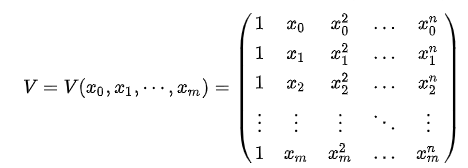

https://en.wikipedia.org/wiki/Vandermonde_matrix

Une matrice de Vandermonde est toujours inversible si les $\alpha_i$ sont tous distincts deux à deux. Ainsi, avec la contrainte de choisir des $x_i$ tous distincts deux à deux, nous nous assurons que notre matrice $X$, que nous nommerons à présent $V$ est toujours inversible. Il nous faut nous intéresser à la nature des $x_i$ qui compose $V$. Comme nous travaillons dans $\mathbf{Z}[X]/X^N+1$, cela signifie que les $x_i$ de notre matrice $V$ doivent respecter la relation $x_i^n +1 =0$. Donc on a : 
$$ \begin{array}{cc}\\
x_{i}^{n} +1=0 \\
x_i^n = -1 \\
x^{2n}_i = (-1)^2 = 1
\end{array}
$$
Donc les $x_i^n = -1$ font partie de l'ensemble des $2n$ ième racines unités. 

https://e.math.cornell.edu/people/belk/numbertheory/CyclotomicPolynomials.pdf

https://en.wikipedia.org/wiki/Cyclotomic_polynomial

De plus, pour trouver les solutions à $x^{2n}_i = 1$, nous pouvons poser
$$\begin{array}{cc}
x^{2n}_i = 1 \\
(x^{n} + 1)(x^{n} - 1) = 0
\end{array}
$$
Nous connaissons déjà les solutions à $x^{2n}_i = 1$, ce sont les $2n$e racines unités, sachant que classiquement, nous avons les $n$e racines unités représentées par l'ensemble de complexes suivant : $\{ \zeta^N = 1 : \zeta = e^{2k \pi i /n }, 0 \leq k < n \}$, donc les $2n$e racines unités sont notées $\{ \zeta^{2N} = 1 : \zeta = e^{2k \pi i / 2N} = e^{k \pi i / n}, 0 \leq k < 2N  \}$. 
Nous, nous cherchons l'ensemble de solutions à $(x^n + 1) = 0$ et nous connaissons les solutions à $X^{2n} - 1 = 0$ ce qui revient à l'ensemble des solutions de $(x^n +1)(x^n -1) = 0$. Donc si nous arrivons à déterminer l'ensemble des solutions de $(x^n -1) = 0$ alors nous pourrons faire :  
$$
\begin{array}{cc}
\{\text{2ne racines unités}\} - \{\text{solutions à }(x^n - 1 = 0)\} = \{\text{solutions à }(x^n + 1 = 0) \}
\end{array}
$$
Donc nous cherchons 
$$
\begin{array}{cc}
x^n - 1 = 0 \\
x^n = 1  \\
\Rightarrow \{\zeta'^n =1 : \zeta' = e^{2k \pi i / n}, 0 \leq k' < n\}
\end{array}
$$
Les solutions à $(x^n + 1 = 0)$ sont les $2ne$ racines unités qui ne sont pas solutions à $(x^n - 1 = 0)$ donc nous cherchons 
$$
\begin{array}{cc}
\{ \zeta^{2N} = 1 : \zeta = e^{2k \pi i / 2N} = e^{k \pi i / n}, 0 \leq k < 2N  \} \neq \{\zeta'^n =1 : \zeta' = e^{2k' \pi i / n}, 0 \leq k' < n\} \\
\zeta = e^{k \pi i /n}, \zeta' = e^{2k' \pi i /n}  \\
\zeta = \zeta' \text{ ssi } k = 2k', \text{ soit } \frac{k}{2} = k'
\end{array}
$$
Comme $k,k' \in \mathbb{Z}$ alors $k$ doit être un multiple de $2$ (un nombre pair). A l'inverse, pour tout les cas où $k$ est impair, ce n'est plus solution à $(x^n =1)$ et donc solution à $(x^n = -1)$. Ainsi, les racines de $(x^n = -1)$ sont les $n$ complexes distincts suivants : 
$$
\begin {array}{cc}
\{\zeta = e^k \pi i /n, 0 \leq k < 2N, 2 \nmid k \} \\
= \omega, \omega^3, \omega^5,\dots, w^{2n -1}
\end{array}
$$


Donc nous pouvons construire une matrice $V$ avec tout les $x_i$ distincts et qui respectent $x_i^n +1 =0$.
$$\begin{pmatrix}  
1 & \omega & \omega^{2} & \cdots & \omega^{n - 1} \\  
1 & \omega^3 & (\omega^{3})^{2} & \cdots & (\omega^3)^{n - 1} \\
1 & \omega^5 & (\omega^{5})^{2} & \cdots & (\omega^5)^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & \omega^{2n-1} & (\omega^{2n-1})^{2} & \cdots & (\omega^{2n-1})^{n - 1}
\end{pmatrix}
$$

Il nous faut vérifier la bijectivité de l'application $V$. En effet, même si le théorème d'interpolation de Lagrange semble nous donner la bijectivité, il faut vérifier que l'on en respecte le cadre : 

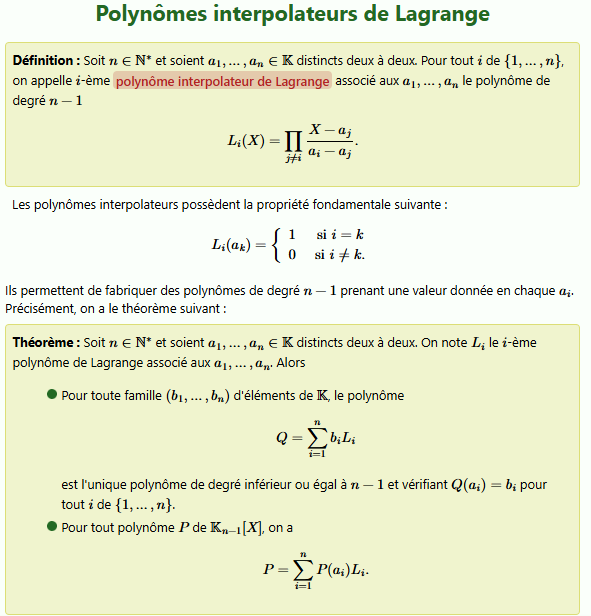

https://www.bibmath.net/dico/index.php?action=affiche&quoi=./p/polynomelagrange.html

Pour plus de lisibilité, nous allons nous servir de la propriété suivante pour notre matrice de Vandermonde $V^{-1}= \frac{V^T \cdot \ I^R_n}{n}$. 

Tout d'abord : 
$$
\begin{array}{cc}
V \cdot V^T = 
\begin{pmatrix}  
1 & \omega & \omega^{2} & \cdots & \omega^{n - 1} \\  
1 & \omega^3 & (\omega^{3})^{2} & \cdots & (\omega^3)^{n - 1} \\
1 & \omega^5 & (\omega^{5})^{2} & \cdots & (\omega^5)^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & \omega^{2n-1} & (\omega^{2n-1})^{2} & \cdots & (\omega^{2n-1})^{n - 1}
\end{pmatrix}
\cdot
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 \\
\omega & \omega^3 & \omega^5 & \cdots & \omega^{2n-1} \\
(\omega)^2 & (\omega^3)^2 & (\omega^5)^2 & \cdots & (\omega^{2n-1})^2 \\
\vdots & & \ddots & & \vdots \\
(\omega)^{n-1} & (\omega^3)^{n-1} & (\omega^5)^{n-1} & \cdots & (\omega^{2n-1})^{n-1}
\end{pmatrix} \\ \\
=
\begin{pmatrix}
\sum_{k=0}^{n-1}\omega^{2k} & \sum_{k=0}^{n-1}\omega^{4k} & \sum_{k=0}^{n-1}\omega^{6k} & \cdots & \sum_{k=0}^{n-1}\omega^{2nk} \\
\sum_{k=0}^{n-1}\omega^{4k} & \sum_{k=0}^{n-1}\omega^{6k} & \sum_{k=0}^{n-1}\omega^{8k} & \cdots & \sum_{k=0}^{n-1}\omega^{2k(n+1)} \\
\sum_{k=0}^{n-1}\omega^{6k} & \sum_{k=0}^{n-1}\omega^{8k} &\sum_{k=0}^{n-1}\omega^{10k} & \cdots & \sum_{k=0}^{n-1}\omega^{2k(n+2)} \\
\vdots & & \ddots & & \vdots \\
\sum_{k=0}^{n-1}\omega^{2nk} & \sum_{k=0}^{n-1}\omega^{2(n+1)k}  &  \sum_{k=0}^{n-1}\omega^{2(n+2)k} & \cdots &  \sum_{k=0}^{n-1}\omega^{2(n+n-1)k}
\end{pmatrix}
\end{array}
$$
Nous pouvons voir que tout les éléments antidiagonales sont $\sum_{k=0}^{n-1}\omega^{2nk}$ donc : 
$$\begin{array}{cc}
\sum_{k=0}^{n-1}\omega^{2nk} \\ 
= \sum_{k=0}^{n-1} e^{(i \pi /n)2nk} \\
= \sum_{k=0}^{n-1} e^{2 i \pi k} \\
= \sum_{k=0}^{n-1} (cos(2 \pi k) + i sin(2 \pi k)) \\
= \sum_{k=0}^{n-1} (1 + 0) = n
\end{array}
$$
Donc les éléments anti-diagonaux sont uniquement $n$. Pour les autres éléments $\sum_{i=0}^{n-1} \omega^{2k}, \sum_{i=0}^{n-1} \omega^{4k}, \dots, \sum_{i=0}^{n-1} \omega^{2(2n-1)k}$ nous pouvons identifier qu'ils sont tous de la forme $\sum_{k=0}^{n-1} \omega^{2(m)k}$ avec $1 \leq m < n-1$. Nous avons grâce à la formule de la somme géométrique : 
$$
\begin{array}{cc}
S_n = \sum_{i=0}^{n-1} x^i = 1 + x + x^2 + \dots + x^{n-1} \\
x \cdot S_n = x + x^2 + x^3 + \dots + x^n \\
x \cdot S_n - S_n = (x + x^2 + x^3 + \dots + x^n) - (1 + x + x^2 + \dots + x^{n-1}) = x^n - 1 \\
S_n \cdot(x - 1) = x^n -1 \\
S_n = \frac{x^n -1}{x - 1} \text{tant que }x \neq 1 \\
\text{Donc } S_n = \sum_{i=0}^{n-1} x^i = 1 + x + x^2 + \dots + x^{n-1} = \frac{x^n -1}{x - 1}
\end{array}
$$

Grâce à cette formule on a : 
$$
\begin{array}{cc}
\sum_{k=0}^{n-1} \omega^{2(m)k} = \frac{\omega^{(2m)n} - 1}{\omega^{2m} - 1} \\
= \frac{\omega^{(2n)m} - 1}{\omega^{2m} - 1} \\
= \frac{1 - 1}{\omega^{2m} - 1} = 0 \text{ tant que } 0 \leq m < n
\end{array}
$$
Ainsi, nous pouvons réécrire l'inverse comme : 
$$V \cdot V^T = 
\begin{pmatrix}
0 & \cdots & 0 & 0 & n \\
0 & \cdots & 0 & n & 0 \\
0 & \cdots & n & 0 & 0 \\
\vdots & & \ddots & & \vdots \\
n & \cdots & 0 & 0 & 0 \\
\end{pmatrix}
 = n \cdot 
\begin{pmatrix}
0 & \cdots & 0 & 0 & 1 \\
0 & \cdots & 0 & 1 & 0 \\
0 & \cdots & 1 & 0 & 0 \\
\vdots & & \ddots & & \vdots \\
1 & \cdots & 0 & 0 & 0 \\
\end{pmatrix}
= n \cdot I^R_n
$$
avec $I^R_n$ la matrice de renversement (elle a pour effet d'échanger l'odre des colonnes, la première passe dernière, la deuxième passe avant dernière...).
A partir de ce résultat : 
$$
\begin{array}{cc}
V \cdot V^T = n \cdot I^R_n \\
V^{-1} \cdot V \cdot V^T = V^{-1} \cdot n \cdot I^R_n \\
V^T = V^{-1} \cdot n \cdot I^R_n \\
\frac{V^T \cdot I^R_n}{n} = V^{-1}
\end{array}
$$


A partir de là, nous pouvons étudier comment seront calculés les coefficients des polynômes, pour voir les contraintes nécessaires pour que les parties imaginaires s'annulent : 
$$
\begin{array}{cc}
V^{-1} \cdot y  = c  \\ \\
\frac{V^T \cdot I^R_n}{n} \cdot y \propto V^T \cdot I^R_n \cdot y \\ \\
\propto 
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 \\
\omega & \omega^3 & \omega^5 & \cdots & \omega^{2n-1} \\
(\omega)^2 & (\omega^3)^2 & (\omega^5)^2 & \cdots & (\omega^{2n-1})^2 \\
\vdots & & \ddots & & \vdots \\
(\omega)^{n-1} & (\omega^3)^{n-1} & (\omega^5)^{n-1} & \cdots & (\omega^{2n-1})^{n-1}
\end{pmatrix}
\cdot 
\begin{pmatrix}
0 & \cdots & 0 & 0 & 1 \\
0 & \cdots & 0 & 1 & 0 \\
0 & \cdots & 1 & 0 & 0 \\
\vdots & & \ddots & & \vdots \\
1 & \cdots & 0 & 0 & 0 \\
\end{pmatrix}
\cdot 
\begin{pmatrix}
y_1 \\
y_2 \\
y_3 \\
\vdots \\
y_n
\end{pmatrix} \\ \\
=   
\begin{pmatrix}
1 & 1 & \cdots & 1 & 1 \\
\omega^{2n-1}  & \omega^{2n-3} & \cdots & \omega^3 & \omega \\
(\omega^{2n-1})^2  & (\omega^{2n-3})^2 & \cdots &  (\omega^3)^2 & (\omega)^2  \\
\vdots & & \ddots & & \vdots \\
(\omega^{2n-1})^{n-1} & (\omega^{2n-3})^{n-1} &  \cdots &  (\omega^3)^{n-1} &  (\omega)^{n-1}
\end{pmatrix}
\cdot 
\begin{pmatrix}
y_1 \\
y_2 \\
y_3 \\
\vdots \\
y_n
\end{pmatrix} \\
= \begin{pmatrix}
\sum_{i=1}^{n}y_i \\
\sum_{i=1}^{n}y_i \omega^{2n - (2i-1)} \\
\sum_{i=1}^{n}y_i \omega^{(2n - (2i-1))^{2}} \\
\vdots \\
\sum_{i=1}^{n}y_i \omega^{(2n - (2i-1))^{n-1}} \\
\end{pmatrix}
\end{array}
$$
Ainsi, nous avons la forme explicite de nos coefficients à un facteur prêt Nous pouvons voir qu'il s'agit de combinaisons linéaires entre nos valeurs en entrées et les points d'évaluation. En entrée, nous avons des $y_i \in \mathbb{C}$ donc  $\sum_{i=0}^{n-1}y_i \in \mathbb{C}$ sauf si les valeurs imaginaires se compensent entre elles. De plus, le produit pondéré des points d'évaluation $\omega_i$ donnera aussi un résultat dans $\mathbb{C}$ sauf si les parties imaginaires des points d'évaluation se compensent entre elles après pondération par les $y_i$. Sans cette annulation de la partie imaginaire, notre vecteur de coefficients de polynôme $c^N \in \mathbf{C}[X]/X^N +1$ et non $\mathbf{Z}[X]/X^N + 1$.
Donc nous voulons nous assurer que 
- $\sum_{i=1}^{n}y_i = a + 0i$ avec $a \in \mathbb{R}$.
- $\sum_{i=1}^{n}y_i \omega^{(2n - (2i-1))b} = a + 0i$ avec $a \in \mathbb{R}, 1 \leq b < n$.

Comme nous voulons que les valeurs du vecteur d'entrée soit à choix libre, il faut construire un $y'$, basé sur $y$ qui respecte $\sum_{i=0}^{n-1}y_i = a + 0i$. Une façon efficace de faire cela est de prendre $y' = (y_1, y_2,\dots, y_n ) | (\overline{y_1}, \overline{y_2}, \dots, \overline{y_n}) = (y_1, y_2,\dots, y_n, \overline{y_1}, \overline{y_2}, \dots, \overline{y_n} ) = (y | \overline{y})$  soit la concaténation de $y$ avec son conjugué. Ainsi, $\sum_{i=0}^{n-1}{y'_i} = a + 0i$.

Pour le deuxième cas, nous avons une somme de produit pondéré, sachant que les $y'$ s'annulent leur partie imaginaire entre eux. Il faudrait donc une symétrie de conjugués sur les $\omega$ pour s'assurer que les parties imaginaires s'annulent bien : 
$$
\begin{array}{cc}
\sum_{i=1}^{n}y'_i \omega^{(2n - (2i-1))b} \\ 
= y_1\omega^{(2n -1)b} + \dots + y_n\omega^{(2n-(n-1))b} + \overline{y_1}\overline{\omega^{(2n-(2n+1)b}} + \dots + \overline{y_n}\overline{\omega^{(2n-1)b}}
\end{array}
$$
De cette façon, les parties imaginaires s'annulent entre elles deux à deux. 
Comme le choix des $\omega$ n'est pas arbitraire, il faut vérifier qu'ils respectent la relation : $\omega_i = \overline{\omega_{2n - i}}$, i.e : 
$$
\begin{array}{cc}
\omega_1 = \overline{\omega_{2n-1}} \\
\omega_3 = \overline{\omega_{2n-3}} \\
\omega_5 = \overline{\omega_{2n-5}} \\
\dots \\
\omega_{n-1} = \overline{\omega_{n+1}} \\
\dots \\
\omega_{2n-1} = \overline{\omega_{1}} \\
\end{array}
$$
Cette relation est vraie et peut être dérivée directement à partir de la formule d'Euler. 
Grâce à cette relation, nous savons que nous avons bien
$$
\begin{array}{cc}
\sum_{i=1}^{n}y'_i \omega^{(2n - (2i-1))b} \\ 
= y_1\omega^{(2n -1)b} + \dots + y_n\omega^{(2n-(n-1))b} + \overline{y_1}\overline{\omega^{(2n-(2n+1))b}} + \dots + \overline{y_n}\overline{\omega^{(2n-1)b}}
\end{array}
$$
Cependant, nous pouvons voir que nous avons $y_n \times \omega^{(2n - (n-1))b} + \overline{y_1} \times \overline{\omega^{(2n - (2n+1))b}}$ . Les parties imaginaires ne sont pas forcées de s'annuler car nous les $y_i$ ne sont pas alignés avec leur $\omega$. Nous souhaitons avoir $y_n \times \omega^{(2n - (n-1))b} + \overline{y_n} \times \overline{\omega^{(2n - (2n+1))b}}$, ce qui nous donnerait dans la somme total : 
$$
\begin{array}{cc}
\sum_{i=1}^{n}y'_i \omega^{(2n - (2i-1))b} \\ 
= y_1\omega^{(2n -1)b} + \dots + y_n\omega^{(2n-(n-1))b} + \overline{y_n}\overline{\omega^{(2n-(2n+1))b}} + \dots + \overline{y_1}\overline{\omega^{(2n -1)b}}
\end{array}
$$

Donc nous devons modifier $y' = (y_1, \dots, y_n, \overline{y_1}, \dots, \overline{y_n}) =(y | \overline{y})$ en $y' = (y_1, \dots, y_n, \overline{y_n}, \dots, \overline{y_1}) = (y | \text{ reverse order}(\overline{y}))$. En construisant $y'$ de cette façon et grâce à la structure particulière de $V$ nous avons donc $\frac{V^T \cdot I^R_N}{n} \cdot y = c \in \mathbb{R}^N$. 

Nous ne faisons plus $\mathbf{R}[X]/X^N +1 \to \mathbb{C}^N$ car il était impossible d'avoir bijectivité (bijectivité uniquement possible pour $\mathbf{C}[X]/X^N +1 \to \mathbb{C}^N$). A la place nous faisons $\mathbf{R}[X]/X^N +1 \to \hat{\mathbb{C}}^N \to \mathbb{C}^{N/2}$. Nous avons réduit notre espace d'entrée par deux.  Cependant, nous ne somme toujours pas dans $\mathbf{Z}[]/X^N +1$. Nous réglerons ce problème plus tard. 
Maintenant que nous avons la bijectivité, nous avons besoin de vérifier que $V$ est aussi homomorphique pour avoir isomorphisme entre l'anneau $\mathbf{R}[X]/X^N +1$ et $\mathbb{C}^{N/2}$. Pour cela, il faut que : 
- $V(c + d) = Vc + Vd$, vérifié par linéarité de matrice 
- $V(c * d) = Vc ? Vd$ avec $?$ une opération multiplicative qui permet à $C^{N/2}$ muni de l'addition et $?$ d'être un anneau. L'opération $*$ désigne la convolution, qui correspond à la multiplication de polynôme. 
Posons deux polynômes $c(X) = \sum_{i=0}^{n-1} c_i X^i;  \ d(X) = \sum_{j=0}^{n-1} d_j X^j$. La multiplication des deux polynômes nous donne : 
$$\begin{array}{cc}\\
c(X)d(X) \\
= (\sum_{i=0}^{n-1} c_i X^i) (\sum_{j=0}^{n-1} d_j X^j) \\
= \sum_{i=0}^{n-1}\sum_{j=0}^{n-1}c_i d_j X^{i+j}
\end{array}
$$
Pour simplifier la démonstration, nous pouvons regarder ce qu'il se passe au niveau d'une composante de $(V(c * d))_k$ qui consiste donc à évaluer le polynômes en la composante $\omega_k$ :
$$\begin{array} {cc}
(V(c * d))_k \\
= (\sum_{i=0}^{n-1} c_i \omega^i_k) (\sum_{j=0}^{n-1} d_j \omega^j_k) \\
= (Vc)_k )(Vd)_k
\end{array}$$
De cette façon le vecteur $V(c * d)$ est constitué des produits suivants : 
$$\begin{pmatrix}
(Vc)_0(Vd)_0 \\
(Vc)_1(Vd)_1 \\
\vdots \\
(Vc)_{n-1}(Vd)_{n-1} \\
\end{pmatrix} = Vc \ \odot \ Vd$$
Ce qui nous donne : 
$$V(c * d) = Vc \ \odot Vd$$
Donc on a un isomorphisme d'anneau $R[X]/X^N +1 \to C^{N/2}$ grâce à $V$ : 
$$\begin{pmatrix}  
1 & \omega & \omega^{2} & \cdots & \omega^{n - 1} \\  
1 & \omega^3 & (\omega^{3})^{2} & \cdots & (\omega^3)^{n - 1} \\
1 & \omega^5 & (\omega^{5})^{2} & \cdots & (\omega^5)^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & \omega^{2n-1} & (\omega^{2n-1})^{2} & \cdots & (\omega^{2n-1})^{n - 1}
\end{pmatrix}
\begin{pmatrix}
c_1 \\
c_2 \\
c_3 \\
\vdots \\
c_n
\end{pmatrix} 
= 
\begin{pmatrix}
y_1 \\
y_2 \\
y_3 \\
\vdots \\
y_n
\end{pmatrix}
$$
soit 
$$Vc = y$$
et donc 
$$V^{-1}y = c$$
C'est sur cet isomorphisme que repose l'encodage de CKKS. Nous prenons en entrée un vecteur de complexes $y$ puis nous le concaténons à son conjugué, pour ensuite l'évaluer en les racines unités pour obtenir les coefficients du polynôme qui servira de vecteur encodé. Pour passer dans l'espace $Z[X]/X^N +1$ nous allons arrondir les coefficient à l'entier le plus proche. Si nous nous contentons de directement arrondir, nous allons perdre énormément de précision. Pour garder le maximum de précision possible, nous multiplions au préalable nos coefficient par un facteur $\Delta$ : $\tilde{c} = \lfloor \Delta c \rceil$. Au final, nous opérons les opérations d'encodage et de décodage suivantes : 
$$
y \in \mathbb{C^{N/2}} \to y' \in \hat{\mathbb{C}}^N \to c \in \mathbf{R}[X]/X^N +1 \to \tilde{c} \in \mathbf{Z}[X]/X^N +1 \to \tilde{y'} \in \hat{\mathbb{C}}^N \to \tilde{y} \in \mathbb{C^{N/2}}
$$

Pour garder les calculs les plus simple possible, nous allons travailler avec des coefficients modulo $t$ pour garder la taille des coefficient plus petit qu'une certaine limite. Pour ce faire, nous allons travailler dans $\mathbf{Z}_t[X]/X^N + 1$. Pour choisir le modulus $t$ nous devons prendre en compte plusieurs facteurs : 
- Nombre d'opérations souhaitées 
- Tailles des messages en entrées 
- Bruit tolérables 
- Cohérent avec la NTT/FTT pour la multiplication optimisée dans $Z[X]/X^N +1$. 

Pour la taille des messages d'entrées, nous devons nous assurer que $\Delta m$ n'overflow pas, donc $\Delta m < t$. 
Les opérations possibles sont l'addition et la multiplication. Donc nous aimerions nous assurer que nous pouvons au moins faire une multiplication ou une addition de deux messages encodés. Evidemment, cela dépend directement de la taille des messages en entrée et de leur taille une fois encodés. Si nous définissons le message de taille maximum $m_{max}$ alors l'addition prend une taille $\Delta m_{max} + \Delta m_{max}$ et la multiplication $\Delta m_{max} \cdot \Delta m_{max}$. En supposant que $\Delta m_{max} \geq 2$  alors $| \Delta m_{max} \cdot \Delta m_{max} | \geq | \Delta m_{max} + \Delta m_{max} |$. Donc il faut choisir $t \geq | \Delta m_{max} \cdot \Delta m_{max} |$. Comme nous travaillons avec des polynômes, il faut s'assurer en réalité qu'aucun des coefficient des polynômes ne soit plus grand que $t$. Posons $|a_i| < B$ pour $a_i$ les coefficients de $\Delta m_{max}$. Ainsi $| \Delta m_{max} \cdot \Delta m_{max} | \leq NB^2$ avec $N$ le degré du polynôme.  Donc il faut au moins prendre $t \geq NB^2$. 

Par ailleurs, nous verrons ultérieurement que CKKS est un schéma lourd computationnellement. Dans l'objectif d'optimiser ce coût, la multiplication est optimisé via Number Theory Transform et Fast Fourrier Transform. Nous verrons cela plus en détail ultérieurement. 













## Application 

Voici un exemple jouet d'encodage et de décodage d'un message. 

### Input

Comme vu précédemment, en entrée, nous prenons un vecteur de complexe de taille $N/2$, avec $N$ une puissance de 2. 

In [1]:
import numpy as np 

power_of_two  = 2
n = 2**power_of_two

# y = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
y = np.array([1.1 +4.3j, 3.5 - 1.4j])
print(y)

[1.1+4.3j 3.5-1.4j]


### Construction de $y'$

Puis nous construisons $y' = (y| \text{ reverse order}(\overline{y}))$. 

In [2]:
y_and_conj = np.concatenate((y, y.conjugate()[::-1]), axis=0)
y_and_conj

array([1.1+4.3j, 3.5-1.4j, 3.5+1.4j, 1.1-4.3j])

### Passage en polynôme cyclotomique à coefficient réels

Nous avons défini $V$, l'isomoprhisme d'anneau $\mathbf{R}[X]/X^N +1 \to \hat{\mathbb{C}^N}$ tel que : 
$V\cdot c = y$. Comme nous partons des complexes et nous voulons obtenir les coefficients du polynômes qui sert d'encodage à notre message, nous cherchons 
$$
\begin{array}{cc}
V^{-1}y = c \\ 
\frac{V^T \cdot I^R_N}{N} \cdot y = c
\end{array}
$$

Pour rappel : 
$$
\begin{array}{cc}
\omega = e^{k \pi i/n} \\ \\
V = 
\begin{pmatrix}  
1 & \omega & \omega^{2} & \cdots & \omega^{n - 1} \\  
1 & \omega^3 & (\omega^{3})^{2} & \cdots & (\omega^3)^{n - 1} \\
1 & \omega^5 & (\omega^{5})^{2} & \cdots & (\omega^5)^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & \omega^{2n-1} & (\omega^{2n-1})^{2} & \cdots & (\omega^{2n-1})^{n - 1}
\end{pmatrix} \\ \\
V^T = 
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 \\
\omega & \omega^3 & \omega^5 & \cdots & \omega^{2n-1} \\
(\omega)^2 & (\omega^3)^2 & (\omega^5)^2 & \cdots & (\omega^{2n-1})^2 \\
\vdots & & \ddots & & \vdots \\
(\omega)^{n-1} & (\omega^3)^{n-1} & (\omega^5)^{n-1} & \cdots & (\omega^{2n-1})^{n-1}
\end{pmatrix} \\ \\ 
I^R_N =  
\begin{pmatrix}
0 & \cdots & 0 & 0 & 1 \\
0 & \cdots & 0 & 1 & 0 \\
0 & \cdots & 1 & 0 & 0 \\
\vdots & & \ddots & & \vdots \\
1 & \cdots & 0 & 0 & 0 \\
\end{pmatrix}
\end{array}
$$

In [3]:
V = np.zeros(shape=(n,n), dtype=complex) # Pour en faire une matrice de type complexe. 
w = np.exp(1j * np.pi / n)
for ligne in range(1, n+1, 1):
    for col in range(n): 
        V[ligne-1,col] = (w**(2*ligne -1))**(col)

np.set_printoptions(linewidth=300)
print(V, V.T, sep="\n\n\n")

[[ 1.        +0.j          0.70710678+0.70710678j  0.        +1.j         -0.70710678+0.70710678j]
 [ 1.        +0.j         -0.70710678+0.70710678j  0.        -1.j          0.70710678+0.70710678j]
 [ 1.        +0.j         -0.70710678-0.70710678j  0.        +1.j          0.70710678-0.70710678j]
 [ 1.        +0.j          0.70710678-0.70710678j  0.        -1.j         -0.70710678-0.70710678j]]


[[ 1.        +0.j          1.        +0.j          1.        +0.j          1.        +0.j        ]
 [ 0.70710678+0.70710678j -0.70710678+0.70710678j -0.70710678-0.70710678j  0.70710678-0.70710678j]
 [ 0.        +1.j          0.        -1.j          0.        +1.j          0.        -1.j        ]
 [-0.70710678+0.70710678j  0.70710678+0.70710678j  0.70710678-0.70710678j -0.70710678-0.70710678j]]


In [4]:
reversal_matrix = np.zeros(shape=(n, n))
for i in range(n): 
    reversal_matrix[i,n-1-i] = 1
reversal_matrix

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.]])

In [5]:
# Exemple de transformation via la reversal matrix 
exemple_matrix = np.array(([1, 2, 3, 4], [5, 6, 7, 8],  [9, 10, 11, 12]))
print(
    exemple_matrix, exemple_matrix @ reversal_matrix, sep="\n\n"
)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

[[ 4.  3.  2.  1.]
 [ 8.  7.  6.  5.]
 [12. 11. 10.  9.]]


In [6]:
v_encoded_as_pol = (V.T @ reversal_matrix)/n @ y_and_conj
v_encoded_as_pol

array([2.3       +0.00000000e+00j, 0.1767767 +2.22044605e-16j, 2.85      +2.22044605e-16j, 1.87383297-2.44249065e-15j])

A cause de la précision de calcul de la machine, la partie imaginaire ne disparaît pas totalement. En python, nous pouvons considérer que $1.00000000e-16 \approx 0$. En appliquant cette approximation à notre résultat, nous obtenons le vecteur encodé suivant : 

In [7]:
v_encoded_as_pol_appr = np.real_if_close(v_encoded_as_pol, tol=1_000)
v_encoded_as_pol_appr

array([2.3       , 0.1767767 , 2.85      , 1.87383297])

Maintenant, nous allons convertir notre polynôme à coefficient réel en polynôme à coefficient entier en arrondissant les valeurs après les avoir multipliées par le fecteur $\Delta$. Le choix de $\Delta$ doit aussi se faire selon le modulo $t$ choisit.

In [8]:
Delta = 1_000
v__int_encoded_as_pol_appr = np.round(Delta * v_encoded_as_pol_appr, 0)
v__int_encoded_as_pol_appr

array([2300.,  177., 2850., 1874.])

Comme vous pouvez le voir, plus la valeur de $\Delta$ sera grande, plus la précision gardée lors de l'arrondi sera importante. Il faut garder en tête qu'il quasiment impossible de garder une précision parfaite en utilisant CKKS, car nous avons une approximation lors de l'encodage en polynôme à cause de la précision limitée des machines, une nouvelle approximation au moment de l'arrondi et nous aurons aussi de l'ajout de bruit lors du chiffrement/déchiffrement et des opérations. 

Notre message est bien encodé. Nous pouvons travailler dans l'espace sur lequel nous allons chiffrer, faire les opérations et déchiffrer. 
Pour le moment, nous pouvons déjà vérifier que le décodage fonctionne correctement en réalisant l'inverse de l'encodage : 
$$ 
\begin{array}{cc}
Enc(y) = \lfloor \Delta (\frac{V^T \cdot I^R_N}{n} \cdot y') \rceil = \tilde{c} \\ \\
Dec((Enc(y))) = V \cdot \frac{1}{\Delta}\tilde{c}
\end{array}
$$

In [9]:
y_estimated = V @ (1/Delta * v__int_encoded_as_pol_appr)
y_estimated

array([1.10003979+4.30027601j, 3.49996021-1.39972399j, 3.49996021+1.39972399j, 1.10003979-4.30027601j])

Le vecteur obtenu correspond à $V \cdot c = (y | \text{reverse order}(\overline{y}))$. Pour récupérer seulement $y$, il faut prendre uniquement la première moitié du résultat. 

In [10]:
print(y, y_estimated, y_estimated[0:2], sep="\n")

[1.1+4.3j 3.5-1.4j]
[1.10003979+4.30027601j 3.49996021-1.39972399j 3.49996021+1.39972399j 1.10003979-4.30027601j]
[1.10003979+4.30027601j 3.49996021-1.39972399j]


### Wrapping up 

Maintenant que la démonstration est faite, je vais construire les fonctions qui permettront d'encoder et decoder facilement nos messages. 

In [11]:
def CKKS_Encoding(m, Delta): 
    n_div_2 = len(m)
    if (n_div_2 & (n_div_2 - 1)) != 0 : 
        n_div_2 = 1 << (n_div_2 - 1).bit_length()
        m = np.concatenate((m, np.zeros(n_div_2 - len(m))), axis=0)
    m_and_conj = np.concatenate((m, m.conjugate()[::-1]), axis=0)
    n = n_div_2*2
    w = np.exp(1j * np.pi / n)
    V = np.zeros(shape=(n,n), dtype=complex) # Pour en faire une matrice de type complexe. 
    for ligne in range(1, n+1, 1):
        for col in range(n): 
            V[ligne-1,col] = (w**(2*ligne -1))**(col)
    reversal_matrix = np.zeros(shape=(n, n))
    for i in range(n): 
        reversal_matrix[i,n-1-i] = 1
    m_encoded_as_pol = (V.T @ reversal_matrix)/n @ m_and_conj
    m_encoded_as_pol_appr = np.real_if_close(m_encoded_as_pol, tol=1_000)
    m_int_encoded_as_pol_appr = np.round(Delta*m_encoded_as_pol_appr, 0)
    return m_int_encoded_as_pol_appr

In [12]:
CKKS_Encoding(m=y, Delta=Delta)

array([2300.,  177., 2850., 1874.])

In [13]:
def CKKS_decoding(m_encoded, Delta):
    n = len(m_encoded)
    w = np.exp(1j * np.pi / n)
    V = np.zeros(shape=(n,n), dtype=complex) # Pour en faire une matrice de type complexe. 
    for ligne in range(1, n+1, 1):
        for col in range(n): 
            V[ligne-1,col] = (w**(2*ligne -1))**(col)
    y_estimated = V @ (1/Delta * m_encoded)
    return y_estimated[0:(n//2)]

In [14]:
CKKS_Encoding(m=y, Delta=Delta)

array([2300.,  177., 2850., 1874.])

In [15]:
CKKS_decoding(m_encoded=CKKS_Encoding(m=y, Delta=Delta), Delta=Delta)

array([1.10003979+4.30027601j, 3.49996021-1.39972399j])

De cette façon, nous pouvons simplement analyser l'impact sur la précision de la valeur de $\Delta$

In [16]:
Delta_values = [1, 10, 100, 500, 1_000, 10_000, 100_000_000_000_000]

for Delta in Delta_values: 
    result = CKKS_decoding(m_encoded=CKKS_Encoding(m=y, Delta=Delta), Delta=Delta)
    print(y, result , sep="\n")
    erreur = (y - result)
    print(f"Erreur de précision pour Delta = {Delta} : {np.round(erreur, 14)}")
    print()

[1.1+4.3j 3.5-1.4j]
[0.58578644+4.41421356j 3.41421356-1.58578644j]
Erreur de précision pour Delta = 1 : [0.51421356-0.11421356j 0.08578644+0.18578644j]

[1.1+4.3j 3.5-1.4j]
[1.09791847+4.38492424j 3.50208153-1.41507576j]
Erreur de précision pour Delta = 10 : [ 0.00208153-0.08492424j -0.00208153+0.01507576j]

[1.1+4.3j 3.5-1.4j]
[1.10498954+4.2995689j 3.49501046-1.4004311j]
Erreur de précision pour Delta = 100 : [-0.00498954+0.0004311j  0.00498954+0.0004311j]

[1.1+4.3j 3.5-1.4j]
[1.09933269+4.2995689j 3.50066731-1.4004311j]
Erreur de précision pour Delta = 500 : [ 0.00066731+0.0004311j -0.00066731+0.0004311j]

[1.1+4.3j 3.5-1.4j]
[1.10003979+4.30027601j 3.49996021-1.39972399j]
Erreur de précision pour Delta = 1000 : [-3.97923264e-05-0.00027601j  3.97923264e-05-0.00027601j]

[1.1+4.3j 3.5-1.4j]
[1.10003979+4.29999317j 3.49996021-1.40000683j]
Erreur de précision pour Delta = 10000 : [-3.97923264e-05+6.83449886e-06j  3.97923264e-05+6.83449887e-06j]

[1.1+4.3j 3.5-1.4j]
[1.1+4.3j 3.5-1.4j

Plus $\Delta$ est élevé, plus les erreurs se réduisent. Cependant, à cause de la précision des machines, lors les valeurs en entrées sont grandes, peu importe le facteur $\Delta$ choisit, nous ne serons pas capable de retrouver les valeurs de départ après encodage et décodage. 